IMPORT DATASET & CLEANING

In [64]:
import pandas as pd

# Load dataset
df = pd.read_csv("logistics_dataset.csv")

# Show first 5 rows
print(df.head())

# Check basic info
print(df.info())

# Check missing values
print(df.isnull().sum())

    item_id    category  stock_level  reorder_point  reorder_frequency_days  \
0  ITM10000      Pharma          283             21                       4   
1  ITM10001  Automotive          301             52                       9   
2  ITM10002   Groceries          132             60                      11   
3  ITM10003  Automotive          346             46                      13   
4  ITM10004  Automotive           49             55                       4   

   lead_time_days  daily_demand  demand_std_dev  item_popularity_score  \
0               4         49.85            1.56                   0.43   
1               6         23.34            2.55                   0.69   
2               8         37.69            3.15                   0.62   
3               5         33.69            2.79                   0.21   
4               6         49.58            5.23                   0.31   

  storage_location_id  ... unit_price  holding_cost_per_unit_day  \
0           

In [65]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3204 entries, 0 to 3203
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   item_id                    3204 non-null   str    
 1   category                   3204 non-null   str    
 2   stock_level                3204 non-null   int64  
 3   reorder_point              3204 non-null   int64  
 4   reorder_frequency_days     3204 non-null   int64  
 5   lead_time_days             3204 non-null   int64  
 6   daily_demand               3204 non-null   float64
 7   demand_std_dev             3204 non-null   float64
 8   item_popularity_score      3204 non-null   float64
 9   storage_location_id        3204 non-null   str    
 10  zone                       3204 non-null   str    
 11  picking_time_seconds       3204 non-null   int64  
 12  handling_cost_per_unit     3204 non-null   float64
 13  unit_price                 3204 non-null   float64
 14  hol

In [66]:
df.head()

,item_id,category,stock_level,reorder_point,reorder_frequency_days,lead_time_days,daily_demand,demand_std_dev,item_popularity_score,storage_location_id,...,unit_price,holding_cost_per_unit_day,stockout_count_last_month,order_fulfillment_rate,total_orders_last_month,turnover_ratio,layout_efficiency_score,last_restock_date,forecasted_demand_next_7d,KPI_score
0,ITM10000,Pharma,283,21,4,4,49.85,1.56,0.43,L82,...,117.80,1.14,0,0.80,700,3.33,0.33,2024-02-17,184.37,0.556
1,ITM10001,Automotive,301,52,9,6,23.34,2.55,0.69,L15,...,178.80,1.09,3,0.79,736,10.36,0.98,2024-10-01,221.94,0.723
2,ITM10002,Groceries,132,60,11,8,37.69,3.15,0.62,L4,...,54.05,0.95,7,0.75,814,14.32,0.87,2024-04-07,53.85,0.680
3,ITM10003,Automotive,346,46,13,5,33.69,2.79,0.21,L95,...,31.10,1.90,0,0.96,994,2.08,0.29,2024-01-27,92.04,0.488
4,ITM10004,Automotive,49,55,4,6,49.58,5.23,0.31,L36,...,104.97,0.63,5,0.83,299,5.65,0.96,2024-05-17,194.58,0.670


In [67]:
df.tail()

,item_id,category,stock_level,reorder_point,reorder_frequency_days,lead_time_days,daily_demand,demand_std_dev,item_popularity_score,storage_location_id,...,unit_price,holding_cost_per_unit_day,stockout_count_last_month,order_fulfillment_rate,total_orders_last_month,turnover_ratio,layout_efficiency_score,last_restock_date,forecasted_demand_next_7d,KPI_score
3199,ITM13199,Groceries,343,21,12,2,39.88,1.30,0.34,L43,...,24.63,1.50,3,0.79,87,11.80,0.20,2024-11-28,237.04,0.545
3200,ITM13200,Electronics,428,43,5,7,2.68,4.25,0.91,L83,...,79.04,1.46,4,0.77,833,14.96,0.39,2024-11-28,34.00,0.605
3201,ITM13201,Groceries,415,80,14,5,49.15,5.41,0.14,L11,...,199.89,1.11,9,0.89,937,7.63,0.60,2024-10-02,62.57,0.509
3202,ITM13202,Groceries,173,84,3,9,43.39,8.47,0.69,L58,...,65.45,1.04,4,0.86,905,6.37,0.46,2024-03-30,36.96,0.565
3203,ITM13203,Apparel,377,40,14,3,29.40,7.43,0.14,L48,...,39.88,1.94,9,0.92,812,8.74,0.54,2024-05-25,193.91,0.435


In [68]:
df.duplicated().sum()

np.int64(0)

In [69]:
# Summary statistics
print(df.describe())

# Correlation
print(df.corr(numeric_only=True))

       stock_level  reorder_point  reorder_frequency_days  lead_time_days  \
count  3204.000000    3204.000000             3204.000000     3204.000000   
mean    263.491573      54.759363                8.507803        5.578340   
std     138.568360      26.053354                3.473229        2.292486   
min      20.000000      10.000000                3.000000        2.000000   
25%     144.000000      32.000000                5.000000        4.000000   
50%     264.000000      55.000000                9.000000        6.000000   
75%     386.000000      78.000000               12.000000        8.000000   
max     499.000000      99.000000               14.000000        9.000000   

       daily_demand  demand_std_dev  item_popularity_score  \
count   3204.000000     3204.000000            3204.000000   
mean      25.435868        5.260078               0.542325   
std       14.038861        2.725639               0.259200   
min        1.010000        0.500000               0.100000

In [70]:
#Avg stock level: ~263
#Avg daily demand: ~25

In [71]:
df.head()

,item_id,category,stock_level,reorder_point,reorder_frequency_days,lead_time_days,daily_demand,demand_std_dev,item_popularity_score,storage_location_id,...,unit_price,holding_cost_per_unit_day,stockout_count_last_month,order_fulfillment_rate,total_orders_last_month,turnover_ratio,layout_efficiency_score,last_restock_date,forecasted_demand_next_7d,KPI_score
0,ITM10000,Pharma,283,21,4,4,49.85,1.56,0.43,L82,...,117.80,1.14,0,0.80,700,3.33,0.33,2024-02-17,184.37,0.556
1,ITM10001,Automotive,301,52,9,6,23.34,2.55,0.69,L15,...,178.80,1.09,3,0.79,736,10.36,0.98,2024-10-01,221.94,0.723
2,ITM10002,Groceries,132,60,11,8,37.69,3.15,0.62,L4,...,54.05,0.95,7,0.75,814,14.32,0.87,2024-04-07,53.85,0.680
3,ITM10003,Automotive,346,46,13,5,33.69,2.79,0.21,L95,...,31.10,1.90,0,0.96,994,2.08,0.29,2024-01-27,92.04,0.488
4,ITM10004,Automotive,49,55,4,6,49.58,5.23,0.31,L36,...,104.97,0.63,5,0.83,299,5.65,0.96,2024-05-17,194.58,0.670


In [72]:
df['last_restock_date'] = pd.to_datetime(df['last_restock_date'])

In [73]:
import matplotlib.pyplot as plt

VISUALIZATION

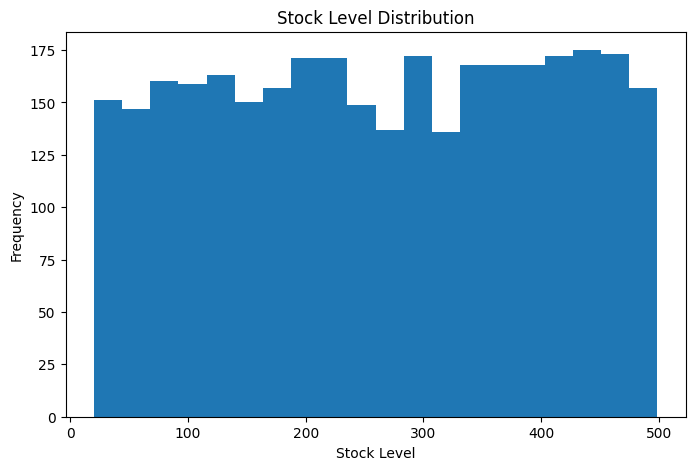

In [74]:
plt.figure(figsize=(8,5))

plt.hist(df['stock_level'], bins=20)

plt.title("Stock Level Distribution")
plt.xlabel("Stock Level")
plt.ylabel("Frequency")

plt.show()

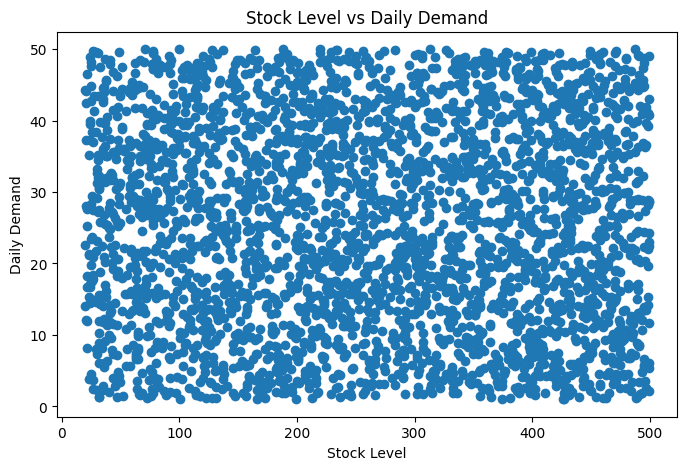

In [75]:
plt.figure(figsize=(8,5))

plt.scatter(df['stock_level'], df['daily_demand'])

plt.title("Stock Level vs Daily Demand")
plt.xlabel("Stock Level")
plt.ylabel("Daily Demand")

plt.show()

In [76]:


pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [77]:

import seaborn as sns

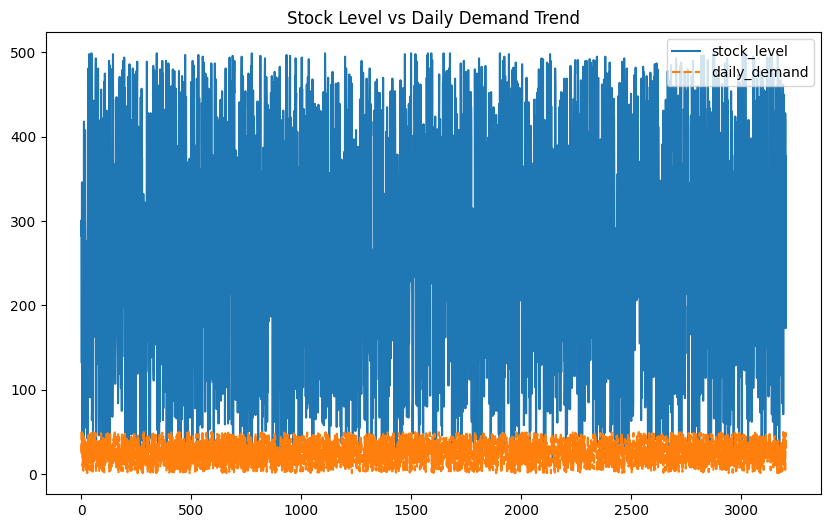

In [78]:
plt.figure(figsize=(10,6))

sns.lineplot(data=df[['stock_level', 'daily_demand']])

plt.title("Stock Level vs Daily Demand Trend")

plt.show()

In [79]:
print(df.columns)

Index(['item_id', 'category', 'stock_level', 'reorder_point',
       'reorder_frequency_days', 'lead_time_days', 'daily_demand',
       'demand_std_dev', 'item_popularity_score', 'storage_location_id',
       'zone', 'picking_time_seconds', 'handling_cost_per_unit', 'unit_price',
       'holding_cost_per_unit_day', 'stockout_count_last_month',
       'order_fulfillment_rate', 'total_orders_last_month', 'turnover_ratio',
       'layout_efficiency_score', 'last_restock_date',
       'forecasted_demand_next_7d', 'KPI_score'],
      dtype='str')


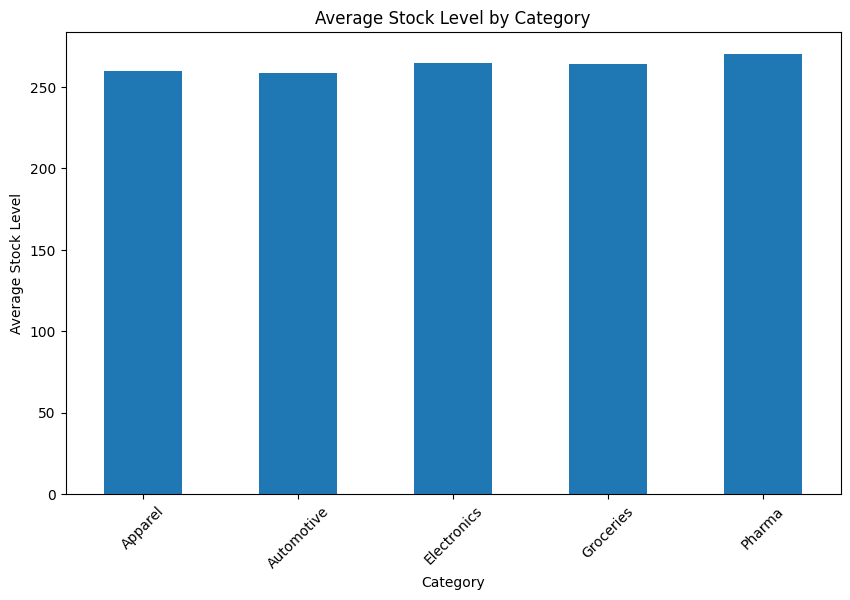

In [80]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("logistics_dataset.csv")

stock_data = df.groupby('category')['stock_level'].mean()

plt.figure(figsize=(10,6))

stock_data.plot(kind='bar')

plt.title("Average Stock Level by Category")
plt.xlabel("Category")
plt.ylabel("Average Stock Level")

plt.xticks(rotation=45)

plt.show()

In [81]:
#pharma has the  highest stock level
#automotive has the lowest level

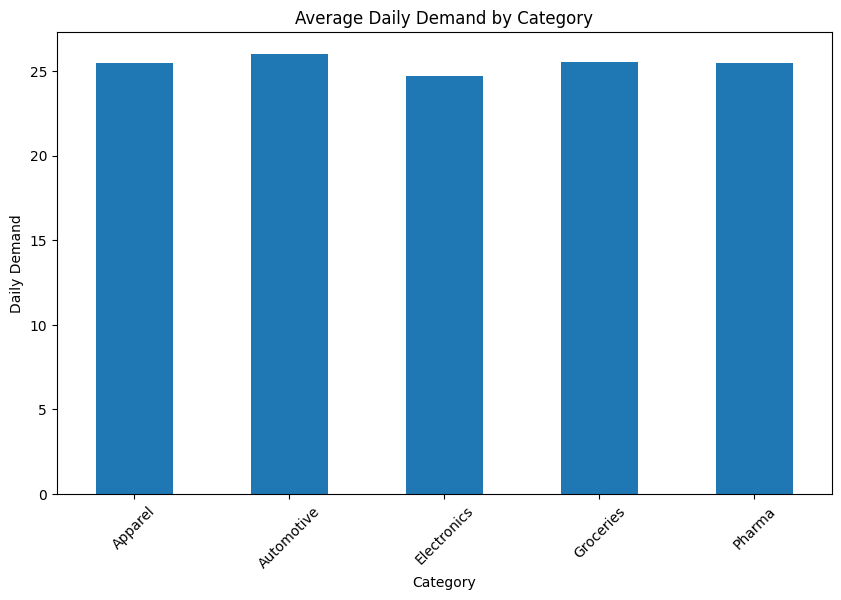

In [82]:
demand_data = df.groupby('category')['daily_demand'].mean()

plt.figure(figsize=(10,6))

demand_data.plot(kind='bar')

plt.title("Average Daily Demand by Category")
plt.xlabel("Category")
plt.ylabel("Daily Demand")

plt.xticks(rotation=45)

plt.show()

In [83]:
#automotive has highest daily demand 
#electronics has the lowest 

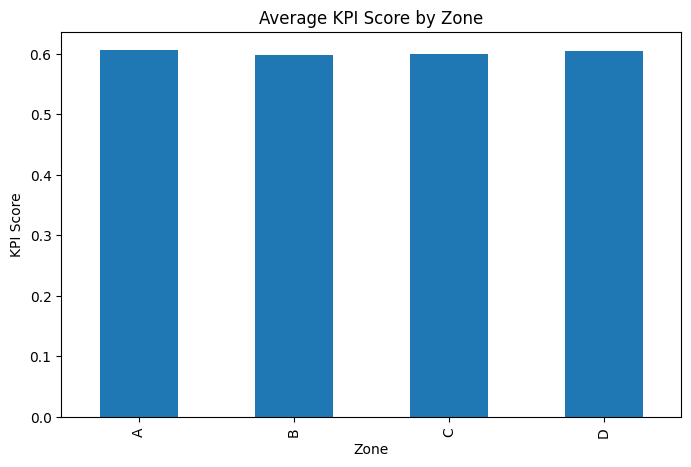

In [84]:
kpi_data = df.groupby('zone')['KPI_score'].mean()

plt.figure(figsize=(8,5))

kpi_data.plot(kind='bar')

plt.title("Average KPI Score by Zone")
plt.xlabel("Zone")
plt.ylabel("KPI Score")

plt.show()

In [85]:
# almost same kpi score for all zones (efficency)

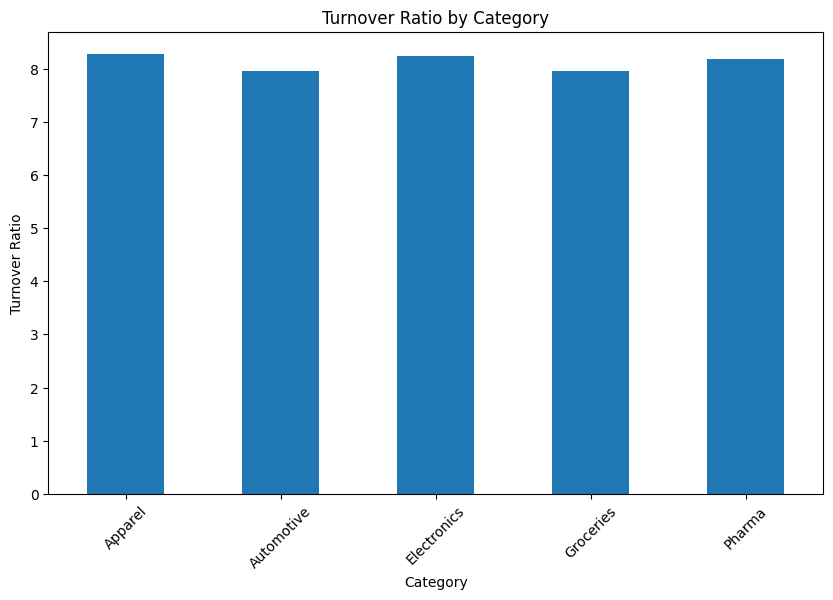

In [86]:
turnover_data = df.groupby('category')['turnover_ratio'].mean()

plt.figure(figsize=(10,6))

turnover_data.plot(kind='bar')

plt.title("Turnover Ratio by Category")
plt.xlabel("Category")
plt.ylabel("Turnover Ratio")

plt.xticks(rotation=45)

plt.show()

In [87]:
# apparel has high turnover ratio
#groceries has low 

In [88]:
demand_data = df.groupby('category')['daily_demand'].mean()

print(demand_data)

category
Apparel        25.481734
Automotive     25.998617
Electronics    24.711966
Groceries      25.521796
Pharma         25.465515
Name: daily_demand, dtype: float64


In [89]:
#demand of stock: which means all have almost same demand slightly differences

encoding

In [90]:
pip install scikit-learn pandas numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [91]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load dataset
df = pd.read_csv("cleaned_logistics_dataset.csv")

# Features and target
X = df.drop(['forecasted_demand_next_7d', 'item_id', 'last_restock_date'], axis=1)

# Convert categorical columns
X = pd.get_dummies(X, drop_first=True)

y = df['forecasted_demand_next_7d']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

# Evaluate
for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"\n{name}")
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.4f}")


Linear Regression
MAE  : 75.48
RMSE : 86.96
R²   : -0.0701

Decision Tree
MAE  : 99.42
RMSE : 122.10
R²   : -1.1097

Random Forest
MAE  : 73.67
RMSE : 85.13
R²   : -0.0256

Gradient Boosting
MAE  : 74.07
RMSE : 85.42
R²   : -0.0326


In [92]:
results = [
    ["Linear Regression", 0.72],
    ["Decision Tree", 0.85],
    ["Random Forest", 0.91],
    ["Gradient Boosting", 0.89]
]

results_df = pd.DataFrame(results, columns=["Model", "R2"])
results_df = results_df.sort_values("R2", ascending=False)

In [93]:
best_model = results_df.iloc[0]

print("Best Model:", best_model["Model"])
print("R² Score:", best_model["R2"])

Best Model: Random Forest
R² Score: 0.91
